Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

# Bibliotecas

In [1]:
!pip install torchinfo

In [2]:
import os                                           # módulo para interagir com o sistema de arquivos (criar pastas, ler arquivos, etc.)
import json                                         # para carregar e salvar dados em formato JSON
import re                                           # expressões regulares para manipulação e validação de strings
import string                                       # utilitários para strings (como lista de pontuações, letras, etc.)
from collections import Counter                     # estrutura de dados para contagem rápida de itens
import numpy as np                                  # biblioteca para cálculo numérico e operações com arrays
import torch                                        # PyTorch: framework de aprendizado profundo
import torch.nn as nn                               # módulos de construção de redes neurais (camadas, funções de perda, etc.)
from torch.utils.data import Dataset, DataLoader    # abstrações para datasets e carregamento de dados (batching, shuffle)
import torch.nn.functional as F                     # funções de ativação, perda e utilitários funcionais
from torchinfo import summary                       # para exibir o resumo ("summary") da arquitetura do modelo em PyTorch
from tqdm.auto import tqdm                          # barra de progresso adaptada ao ambiente (notebook/terminal) para loops longos
from torch.utils.data import random_split           # utilitário para dividir um Dataset em subconjuntos (ex.: treino/teste)
import matplotlib.pyplot as plt                     # biblioteca para gerar gráficos (ex.: curva de perda por época)
import gdown                                        # utilitário para baixar arquivos do Google Drive via link público

In [3]:
print(f'Versão do pytorch: {torch.__version__}.')  # exibe a versão instalada do PyTorch

Versão do pytorch: 2.7.1+cu128.


In [4]:
# Configurações do Jupyter/Colab:
%matplotlib inline

# Hiperparâmetros

In [6]:
VOCAB_SIZE    = 10_000  # tamanho máximo do vocabulário (número de tokens distintos considerados)
MAX_LEN       = 200     # comprimento máximo de cada sequência de entrada (número de tokens)
EMBEDDING_DIM = 100     # dimensão dos vetores de embedding que representam cada token
N_UNITS       = 128     # número de unidades (neurônios) na camada recorrente (LSTM/GRU/RNN)
BATCH_SIZE    = 32      # tamanho do lote (batch) usado em cada atualização de gradiente
EPOCHS        = 25      # número de épocas de treinamento (passadas completas pelo conjunto de treino)
LEARNING_RATE = 1e-3    # taxa de aprendizado do otimizador (passo de atualização dos parâmetros)
DEVICE = (              # dispositivo de computação: tipo de acelerador (GPU/MPS) se disponível, caso contrário "cpu"
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

In [7]:
print(f'Dispositivo: {DEVICE}')  # Exibe qual dispositivo está sendo usado

Dispositivo: cuda


# Dados: [Epicurious - Recipes with Rating and Nutrition](https://www.kaggle.com/datasets/hugodarwood/epirecipes)

## Baixa os dados

In [8]:
url = 'https://drive.google.com/file/d/1gzDjjou1lbCU87H_rDg5mhAJlkqTTqgn/view?usp=sharing'  # URL pública do arquivo no Google Drive
output = 'full_format_recipes.json'                                                         # nome do arquivo local onde o JSON será salvo
if not os.path.isfile(output):                                                              # verifica se o arquivo ainda não existe no diretório atual
    print(f"Arquivo '{output}' não encontrado. Fazendo download...")                        # informa que o download será realizado
    gdown.download(url=url, output=output, quiet=False, fuzzy=True)                         # baixa o arquivo do Google Drive para o caminho especificado
else:
    print(f"Arquivo '{output}' já existe. Pulando download.")                               # informa que o arquivo já existe e evita novo download

Arquivo 'full_format_recipes.json' já existe. Pulando download.


## Carrega os dados

In [9]:
with open("./full_format_recipes.json") as json_data:           # abre o arquivo JSON de receitas em modo leitura
    recipe_data = json.load(json_data)                          # carrega o conteúdo do arquivo como uma lista de dicionários
print(f'tipo de recipe_data: {type(recipe_data)}')              # mostra o tipo da variável recipe_data (list)
print(f'tipo de recipe_data[indice]: {type(recipe_data[0])}')   # mostra o tipo de um elemento de recipe_data (dict)

tipo de recipe_data: <class 'list'>
tipo de recipe_data[indice]: <class 'dict'>


## Inspeciona os dados

In [10]:
for k, v in recipe_data[0].items():  # percorre todos os pares (chave, valor) do primeiro dicionário de receita
    print(f'{k}: {v}')               # imprime cada chave e seu valor para inspecionar a estrutura dos dados

directions: ['1. Place the stock, lentils, celery, carrot, thyme, and salt in a medium saucepan and bring to a boil. Reduce heat to low and simmer until the lentils are tender, about 30 minutes, depending on the lentils. (If they begin to dry out, add water as needed.) Remove and discard the thyme. Drain and transfer the mixture to a bowl; let cool.', '2. Fold in the tomato, apple, lemon juice, and olive oil. Season with the pepper.', '3. To assemble a wrap, place 1 lavash sheet on a clean work surface. Spread some of the lentil mixture on the end nearest you, leaving a 1-inch border. Top with several slices of turkey, then some of the lettuce. Roll up the lavash, slice crosswise, and serve. If using tortillas, spread the lentils in the center, top with the turkey and lettuce, and fold up the bottom, left side, and right side before rolling away from you.']
fat: 7.0
date: 2006-09-01T04:00:00.000Z
categories: ['Sandwich', 'Bean', 'Fruit', 'Tomato', 'turkey', 'Vegetable', 'Kid-Friendly',

## Filtra os dados

In [11]:
filtered_data = [                                                   # lista de strings (uma por receita) que será usada como corpus de texto
    "Recipe for " + x["title"] + " | " + " ".join(x["directions"])  # monta um texto único: título + '|' + instruções concatenadas
    for x in recipe_data                                            # percorre cada dicionário de receita carregado do JSON original
    if "title" in x                                                 # garante que a chave "title" existe no dicionário
    and x["title"] is not None                                      # garante que o título não é nulo
    and "directions" in x                                           # garante que a chave "directions" existe no dicionário
    and x["directions"] is not None                                 # garante que as instruções não são nulas
]

## Conta o número de receitas

In [12]:
n_recipes = len(filtered_data)                 # conta quantas receitas válidas foram filtradas para o corpus
print(f"{n_recipes} receitas carregadas.")     # exibe na tela o número total de receitas carregadas

20111 receitas carregadas.


## Mostra um exemplo

In [13]:
exemplo = filtered_data[0]  # seleciona a primeira receita filtrada como exemplo de texto bruto
print(exemplo)              # imprime o texto dessa receita para inspeção visual

Recipe for Lentil, Apple, and Turkey Wrap  | 1. Place the stock, lentils, celery, carrot, thyme, and salt in a medium saucepan and bring to a boil. Reduce heat to low and simmer until the lentils are tender, about 30 minutes, depending on the lentils. (If they begin to dry out, add water as needed.) Remove and discard the thyme. Drain and transfer the mixture to a bowl; let cool. 2. Fold in the tomato, apple, lemon juice, and olive oil. Season with the pepper. 3. To assemble a wrap, place 1 lavash sheet on a clean work surface. Spread some of the lentil mixture on the end nearest you, leaving a 1-inch border. Top with several slices of turkey, then some of the lettuce. Roll up the lavash, slice crosswise, and serve. If using tortillas, spread the lentils in the center, top with the turkey and lettuce, and fold up the bottom, left side, and right side before rolling away from you.


# Tokenização e criação do conjunto de dados processado

In [14]:
class EpicuriousRecipesDataset(Dataset):
    """
    Dataset de receitas do Epicurious para modelagem auto-regressiva.

    Esta classe:
    - normaliza e tokeniza textos de receitas (título + instruções),
    - constrói um vocabulário limitado ao `vocab_size` mais frequentes,
    - codifica cada texto como uma sequência fixa de IDs (com padding/truncamento),
    - fornece pares (x, y) para treinamento auto-regressivo, com y deslocado em 1 token.

    Parameters
    ----------
    texts : list of str
        Lista de textos brutos de entrada (uma string por receita).
    vocab_size : int, optional
        Tamanho máximo do vocabulário (incluindo os tokens especiais) (default = 10_000).
    max_len : int, optional
        Comprimento máximo das sequências (em tokens) usado para cada exemplo (default = 200).

    Attributes
    ----------
    max_len : int
        Comprimento máximo das sequências (sem contar o deslocamento extra, internamente usa max_len + 1).
    pad_id : int
        Índice reservado para o token de padding ``<PAD>``.
    unk_id : int
        Índice reservado para o token desconhecido ``<UNK>``.
    cleaned : list of str
        Lista de textos após normalização (pontuação separada e minúsculas).
    itos : list of str
        Vocabulário na ordem índice → token (index-to-string).
    stoi : dict
        Dicionário de token → índice (string-to-index).
    data : list of torch.Tensor
        Lista de tensores de inteiros com IDs de tokens, já com padding/truncamento aplicado.
    """
    def __init__(self, texts, vocab_size=10_000, max_len=200):
        """
        Inicializa o dataset de receitas para modelagem auto-regressiva.

        Parameters
        ----------
        texts : list of str
            Lista de textos brutos (uma string por receita), tipicamente "título | instruções".
        vocab_size : int, optional
            Tamanho máximo do vocabulário, incluindo os tokens especiais <PAD> e <UNK> (default = 10_000).
        max_len : int, optional
            Comprimento máximo da sequência de entrada (em tokens) usada por exemplo; internamente
            é construída uma sequência de tamanho ``max_len + 1`` para formar os pares (x, y) (default = 200).

            Exemplo
            -------
            Suponha `max_len = 4`. Depois de tokenizar/pad/truncar, para uma receita
            temos internamente uma sequência de 5 tokens:

                seq = [t0, t1, t2, t3, t4]  (tamanho = max_len + 1 = 5)

            A partir dela, construímos:

                x = seq[:-1] = [t0, t1, t2, t3]  (tamanho = max_len = 4)
                y = seq[1:]  = [t1, t2, t3, t4]  (tamanho = max_len = 4)

            Ou seja, para treinamento do modelo auto-regressivo, cada exemplo é um par:

                entrada: (x(0), x(1), ..., x(max_len - 1)) = (t0, t1, t2, t3)
                alvo:    (x(1), x(2), ..., x(max_len))     = (t1, t2, t3, t4)

        """

        self.cleaned = [self._pad_punct(text) for text in texts]         # gera lista de textos normalizados (minúsculas, pontuação e espaços tratados)

        # construção do vocabulário
        self.itos, self.stoi = self._build_vocab(self.cleaned,           # constrói o vocabulário a partir dos textos normalizados, retornando mapeamentos índice→token (itos) e token→índice (stoi)
                                                vocab_size,
                                                pad_token="<PAD>",
                                                unk_token="<UNK>")
        self.pad_id = self.stoi["<PAD>"]                                # índice (= 0) reservado para o token de padding <PAD> (usado para preencher sequências curtas até o comprimento fixo)
        self.unk_id = self.stoi["<UNK>"]                                # índice (= 1) reservado para o token desconhecido <UNK> ( usado quando um token não existe no vocabulário aprendido)

        self.max_len = max_len                                          # comprimento máximo da sequência (número de tokens considerados por exemplo)
        self.data = self._encode_and_pad()                              # codifica textos normalizados em IDs e aplica padding/truncamento para max_len + 1

    @staticmethod
    def _pad_punct(s: str) -> str:
        """
        Normaliza uma string (letras minúsculas, tratamento sistemático da pontuação e de espaços).

        Parameters
        ----------
        s : str
            String a ser normalizada.

        Returns
        -------
        str
            String normalizada.
        """
        s = re.sub(f"([{re.escape(string.punctuation)}])", r" \1 ", s)  # insere espaço ao redor de cada sinal de pontuação
        s = re.sub(" +", " ", s).lower()                                # reduz múltiplos espaços a um único espaço e converte todas as letras para minúsculas
        return s

    @staticmethod
    def _build_vocab(cleaned_texts, vocab_size, pad_token="<PAD>", unk_token="<UNK>"):
        """
        Constrói o vocabulário a partir de uma lista de textos normalizados.

        Parameters
        ----------
        cleaned_texts : list of str
            Lista de strings normalizadas.
        vocab_size : int
            Tamanho máximo do vocabulário (incluindo tokens especiais).
        pad_token : str, optional
            Token especial usado para padding (default = "<PAD>").
        unk_token : str, optional
            Token especial usado para tokens desconhecidos (default = "<UNK>").

        Returns
        -------
        itos : list of str
            Lista de tokens na ordem índice → token.
        stoi : dict
            Dicionário token → índice.
        """

        # contabiliza a frequência global de cada token no corpus
        counter = Counter()                                             # contador de frequência de tokens no corpus
        for text in cleaned_texts:                                      # percorre cada texto normalizado
            counter.update(text.split())                                # atualiza o contador com os tokens desse texto

        # seleciona os tokens mais comuns, reservando 2 posições para pad_token e unk_token
        most_common = counter.most_common(vocab_size - 2)               # pega os (vocab_size-2) tokens mais frequentes

        # lista que mapeia índice -> token
        itos = [pad_token, unk_token] + [w for w, _ in most_common]     # cria lista de tokens na ordem dos índices

        # dicionário que mapeia token -> índice
        stoi = {w: i for i, w in enumerate(itos)}                       # cria mapeamento inverso de token para índice

        return itos, stoi

    def _encode_and_pad(self):
            """
            Converte os textos normalizados em sequências de IDs com tamanho fixo (max_len + 1).

            Usa:
            - self.cleaned : lista de textos normalizados;
            - self.stoi    : dicionário token → índice;
            - self.pad_id  : índice do token <PAD>;
            - self.unk_id  : índice do token <UNK>;
            - self.max_len : comprimento máximo da sequência de entrada.

            Returns
            -------
            list of torch.Tensor
                Lista de tensores de inteiros com IDs de tokens,
                todos com comprimento ``self.max_len + 1``.
            """

            data = []                                                           # lista que armazenará as sequências tokenizadas como tensores

            for text in self.cleaned:                                           # percorre cada texto normalizado

                tokens = text.split()                                           # divide o texto em tokens por espaço

                ids = [self.stoi.get(t, self.unk_id) for t in tokens]           # converte tokens em IDs, usando unk_id quando token não está no vocabulário

                if len(ids) < (self.max_len + 1):                               # verifica se a sequência é menor que o tamanho desejado (max_len + 1)
                    ids += [self.pad_id] * ((self.max_len + 1) - len(ids))      # se a sequência for curta, completa a sequência com <PAD> até o comprimento fixo (max_len + 1)
                else:
                    ids = ids[: (self.max_len + 1)]                             # se a sequência for longa, recorta a sequência para o tamanho máximo permitido (max_len + 1 )

                data.append(torch.tensor(ids, dtype=torch.long))                # converte a sequência para tensor de inteiros (IDs de tokens) e adiciona à lista
            return data

    def __len__(self):
        """
        Retorna o número de exemplos disponíveis no dataset.

        Returns
        -------
        int
            Quantidade de sequências armazenadas em ``self.data``.
        """
        return len(self.data)  # número total de exemplos (sequências) no dataset

    def __getitem__(self, idx):
        """
        Retorna o par (x, y) no índice especificado, para treinamento auto-regressivo.

        Para uma sequência interna de tamanho ``max_len + 1``, este método produz:
        - x: tokens de posição 0 até max_len - 1
        - y: tokens de posição 1 até max_len

        Ou seja, y é a mesma sequência de x deslocada em 1 passo para a direita, o que
        permite treinar o modelo a prever o próximo token a cada posição.

        Parameters
        ----------
        idx : int
            Índice do exemplo desejado no dataset.

        Returns
        -------
        x : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens de entrada.
        y : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens-alvo (sequência deslocada).
        """
        seq = self.data[idx]   # sequência completa de IDs para este exemplo (tamanho max_len + 1)
        x = seq[:-1]           # entrada: todos os tokens exceto o último (posição 0 até max_len - 1)
        y = seq[1:]            # alvo: todos os tokens exceto o primeiro (posição 1 até max_len)
        return x, y            # retorna o par (x, y) = (entrada, alvo) para modelagem auto-regressiva

In [15]:
ds = EpicuriousRecipesDataset(filtered_data, vocab_size=VOCAB_SIZE, max_len=200)

In [16]:
# um exemplo convertido a IDs (pares x, y para a receita de índice 9)
x, y = ds[9]

print("x (entrada)  - shape:", x.shape)  # tensor de entrada: sequência de tokens usada como contexto
print("x (entrada)  - IDs:  ", x)        # IDs dos tokens de entrada (sem o último token da sequência)

print("y (alvo)     - shape:", y.shape)  # tensor alvo: sequência de próximos tokens a serem previstos
print("y (alvo)     - IDs:  ", y)        # IDs dos tokens alvo (mesma sequência de x, deslocada em 1)

x (entrada)  - shape: torch.Size([200])
x (entrada)  - IDs:   tensor([  26,   16,  557, 8633,    8,  298,  335,  189,    4, 1052,  494,   27,
         332,  228,  235,  262,    5,  594,   11,  133,   22,  311,    2,  332,
          45,  262,    4,  671,    4,   70,    8,  171,    4,   81,    6,    9,
          65,   80,    3,  121,    3,   59,   12,    2,  299,    3,   88,  649,
          20,   39,    6,    9,   29,   21,    4,   67,  529,   11,  164,    2,
         320,  171,  102,    9,  374,   13,  642,  306,   25,   21,    8,  649,
           4,   42,    5,  930,    2,   63,    8,   24,    4,   33,    2,  114,
          21,    6,  178,  181, 1244,    4,   60,    5,  140,  112,    3,   48,
           2,  117,  557,    8,  284,  235,    4,  200,  292,  979,    2,  107,
         649,   28,   72,    4,  108,   10,  114,    3,   57,  204,   11,  172,
           2,   73,  110,  482,    3,  298,    3,  190,    3,   11,   23,   32,
         142,   24,    3,    4,   11,   23,   32,  142,   

In [17]:
N = len(ds)                                                # número total de exemplos disponíveis no dataset completo
N_train = int(0.9 * N)                                     # define 90% dos exemplos para o conjunto de treinamento
N_test  = N - N_train                                      # define os 10% restantes para o conjunto de teste

train_ds, test_ds = random_split(
    ds,
    [N_train, N_test],                                     # tamanhos desejados para os subconjuntos (treino e teste)
    generator=torch.Generator().manual_seed(42)            # fixa a semente para obter sempre o mesmo split (reprodutibilidade)
)

In [18]:
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # DataLoader de treinamento: agrupa exemplos em lotes e embaralha a cada época
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)  # DataLoader de teste: agrupa exemplos em lotes, mantendo a ordem fixa

In [19]:
# inspeciona os primeiros 10 pares índice -> token do vocabulário
print('índice: token')
for i, tok in enumerate(ds.itos[:10]):           # percorre os 10 primeiros índices da lista itos
    print(f"{i:>6}: {tok}")                      # imprime o índice e o token correspondente

índice: token
     0: <PAD>
     1: <UNK>
     2: .
     3: ,
     4: and
     5: to
     6: in
     7: the
     8: with
     9: a


In [20]:
# inspeciona os primeiros 10 pares token -> índice do vocabulário
print('{token: índice}')
for palavra, idx in list(ds.stoi.items())[:10]:  # percorre os 10 primeiros itens do dicionário stoi
    print(f"{palavra:>6}: {idx}")                # imprime o token e o índice correspondente

{token: índice}
 <PAD>: 0
 <UNK>: 1
     .: 2
     ,: 3
   and: 4
    to: 5
    in: 6
   the: 7
  with: 8
     a: 9


# Redes Neurais Recorrentes

## [LSTM](https://pt.wikipedia.org/wiki/Long_short-term_memory) ([pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html))

In [45]:
class RNN_GRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):

        super().__init__()

        ############################################################################
        # Camada de embedding
        ############################################################################
        self.embedding = nn.Embedding(      # mapeia cada índice de token para um vetor denso de dimensão embedding_dim
            vocab_size,                     # tamanho do vocabulário: número total de tokens distintos (IDs de 0 a vocab_size-1)
            embedding_dim,                  # dimensão do vetor de embedding associado a cada token
            padding_idx=0                   # índice reservado para <PAD>; seu embedding fica fixo (tipicamente vetor de zeros) e não é treinado
        )

        ############################################################################
        # Camada GRU
        ############################################################################
        self.gru = nn.GRU(                # recebe a sequência de embeddings e produz uma sequência de estados ocultos
            input_size=embedding_dim,       # dimensão do vetor de entrada em cada passo de tempo (igual à dimensão do embedding)
            hidden_size=hidden_size,        # tamanho do estado oculto da GRU (número de unidades/neurônios na camada recorrente)
            batch_first=True                # indica que a entrada/saída tem formato [batch_size, seq_len, features] em vez de [seq_len, batch_size, features]
        )

        ############################################################################
        # Camada linear de saída
        ############################################################################
        self.fc = nn.Linear(                # projeta cada estado oculto para o espaço de logits sobre o vocabulário
            hidden_size,                    # dimensão de entrada: tamanho do estado oculto produzido pela LSTM em cada passo de tempo
            vocab_size                      # dimensão de saída: número de classes (um logit por token do vocabulário)
        )

    def forward(self, x):
        # x: tensor [batch_size, seq_len] com índices inteiros dos tokens

        emb = self.embedding(x)          # converte índices em embeddings: [batch_size, seq_len, embedding_dim]

        gru_out, _ = self.gru(emb)     # processa a sequência na GRU: [batch_size, seq_len, hidden_size]

        logits = self.fc(gru_out)       # gera logits para cada posição da sequência: [batch_size, seq_len, vocab_size]

        return logits                    # retorna os logits para cada token da sequência

### Instanciar o modelo

In [47]:
modelo_gru = RNN_GRU(vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_size=N_UNITS).to(DEVICE)

### Ver arquitetura do modelo

In [48]:
summary(modelo_gru,
        input_size=(BATCH_SIZE, MAX_LEN),
        dtypes=[torch.long],
        col_names=["input_size", "output_size", "num_params", "trainable"],
        verbose=2)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
RNN_GRU                                  [32, 200]                 [32, 200, 10000]          --                        True
├─Embedding: 1-1                         [32, 200]                 [32, 200, 100]            1,000,000                 True
│    └─weight                                                                                └─1,000,000
├─GRU: 1-2                               [32, 200, 100]            [32, 200, 128]            88,320                    True
│    └─weight_ih_l0                                                                          ├─38,400
│    └─weight_hh_l0                                                                          ├─49,152
│    └─bias_ih_l0                                                                            ├─384
│    └─bias_hh_l0                                                                          

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
RNN_GRU                                  [32, 200]                 [32, 200, 10000]          --                        True
├─Embedding: 1-1                         [32, 200]                 [32, 200, 100]            1,000,000                 True
│    └─weight                                                                                └─1,000,000
├─GRU: 1-2                               [32, 200, 100]            [32, 200, 128]            88,320                    True
│    └─weight_ih_l0                                                                          ├─38,400
│    └─weight_hh_l0                                                                          ├─49,152
│    └─bias_ih_l0                                                                            ├─384
│    └─bias_hh_l0                                                                          

# Treinamento

In [49]:
def compute_nll(logits, targets, loss_fn):
    """
    Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL) agregada sobre todos os tokens do batch,
    reformatando logits e alvos para o shape esperado por CrossEntropyLoss.

    Parameters
    ----------
    logits : torch.Tensor
        Tensor de logits com shape [B, L, V], onde:
        B = batch_size, L = comprimento da sequência, V = tamanho do vocabulário.
    targets : torch.Tensor
        Tensor de alvos com shape [B, L], contendo IDs de tokens.
    loss_fn : torch.nn.Module
        Instância de função de perda (ex.: nn.CrossEntropyLoss)

    Returns
    -------
    torch.Tensor
        Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
    """
    B, L, V = logits.shape                          # B: batch_size, L: seq_len, V: vocab_size
    loss = loss_fn(
        logits.view(B * L, V),   # reshape de [B, L, V] -> [N, C], onde:
                                    #   N = B*L (um "exemplo" por token do lote)
                                    #   C = V   (número de classes = tamanho do vocabulário)
                                    # CrossEntropyLoss espera entradas nesse formato [N, C].
        targets.view(B * L)      # reshape de [B, L] -> [N], com:
                                    #   N = B*L (um rótulo inteiro para cada token do lote)
                                    # CrossEntropyLoss espera alvos 1D [N] alinhados com as linhas de input.
    )
    return loss

In [50]:
def train_autoregressive_model(model, train_dl):
    """
    Treina um modelo auto-regressivo (LSTM/GRU/RNN clássica) em um DataLoader de pares (x, y).

    Cada exemplo do DataLoader deve ter o formato:
    - x: tensor [B, L] com IDs de tokens de entrada;
    - y: tensor [B, L] com IDs de tokens-alvo, deslocados em 1 passo no tempo
         (ou seja, y contém os "próximos tokens" que o modelo deve prever).

    A função treina o modelo por EPOCHS épocas e devolve, para cada época,
    a perda média de treinamento (NLL média por token não-PAD, de acordo com CrossEntropyLoss).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo recorrente (por exemplo, LSTM, GRU ou RNN clássica) que recebe
        tensores [B, L] e retorna logits [B, L, V], onde V é o tamanho do vocabulário.
    train_dl : torch.utils.data.DataLoader
        DataLoader que produz lotes (x_batch, y_batch) de tensores inteiros com IDs
        de tokens de entrada e de tokens-alvo.

    Returns
    -------
    list of float
        Lista contendo a perda média de treinamento em cada época.
    """

    model.to(DEVICE)                                                        # garante que o modelo está no mesmo dispositivo dos lotes (CPU ou GPU)

    loss_fn = nn.CrossEntropyLoss(ignore_index=0, reduction="mean")         # função de perda: entropia cruzada ignorando o token <PAD> (ID 0) no cálculo da média

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)      # otimizador Adam com taxa de aprendizado definida em LEARNING_RATE

    epoch_losses = []                                                       # lista para armazenar a perda média de cada época


    pbar = tqdm(range(1, EPOCHS + 1), desc="Época", unit="época") # barra de progresso sobre as épocas

    for epoch in pbar:                                      # loop externo sobre as épocas de treinamento

        model.train()                                                       # coloca o modelo em modo de treinamento
        running_loss = 0.0                                                  # acumulador da perda ao longo dos lotes desta época

        for x_batch, y_batch in train_dl:                                   # loop interno sobre os lotes produzidos pelo DataLoader de treino

            x_batch = x_batch.to(DEVICE)                                    # envia o lote de entradas para o dispositivo (forma: [B, L])
            y_batch = y_batch.to(DEVICE)                                    # envia o lote de alvos para o dispositivo (forma: [B, L])

            logits = model(x_batch)                                         # obtém logits do modelo: [B, L, V] (um vetor de logits por token)
            loss = compute_nll(logits, y_batch, loss_fn)                    # calcula a NLL agregada de acordo com o reduction da loss_fn (aqui: média por token não-PAD)
            loss.backward()                                                 # calcula gradientes da loss em relação aos parâmetros do modelo
            optimizer.step()                                                # atualiza os parâmetros do modelo usando os gradientes
            optimizer.zero_grad()                                           # zera gradientes acumulados de iterações anteriores

            running_loss += loss.item()                                     # acumula o valor escalar da perda deste lote

        avg_loss = running_loss / len(train_dl)                             # perda média da época (média das losses de todos os lotes)
        epoch_losses.append(avg_loss)                                       # armazena a perda média desta época

        # print(f"Epoch {epoch:>2}, train loss: {avg_loss:.4f}")              # imprime o progresso do treinamento

        pbar.set_postfix({"função de perda": f"{avg_loss:.4f}"})            # atualiza o texto da barra de progresso com a loss da época

    return epoch_losses                                                     # retorna a lista com a perda média de cada época

In [52]:
losses_gru = train_autoregressive_model(modelo_gru, train_dl)

Época:   0%|          | 0/25 [00:00<?, ?época/s]

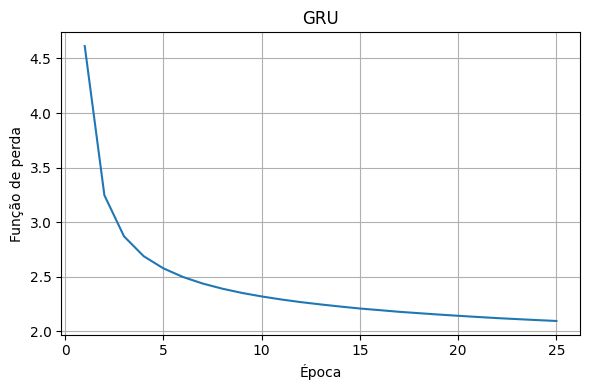

In [53]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, EPOCHS + 1), losses_gru)
plt.xlabel("Época")
plt.ylabel("Função de perda")
plt.title("GRU")
plt.grid(True)
plt.tight_layout()
plt.show()

# Geração de texto

In [54]:
class TextGenerator:
    """
    Gerador de texto auto-regressivo, a partir de um modelo treinado.

    Esta classe recebe um modelo que, dado um tensor de índices de tokens
    com shape [B, L], devolve logits [B, L, V]. A partir disso, permite
    gerar texto token a token, usando amostragem com temperatura ou modo
    guloso (greedy).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo de linguagem treinado que recebe entradas [B, L] e retorna
        logits [B, L, V].
    itos : list of str
        Lista de mapeamento índice -> token (index-to-string).
    device : str or torch.device, optional
        Dispositivo onde o modelo será executado (por exemplo, "cpu" ou "cuda").
        (default = "cpu")
    """

    def __init__(self, model, itos, device="cpu"):
        self.model = model.to(device)                    # envia o modelo para o dispositivo (CPU ou GPU)
        self.itos = itos                                 # lista índice -> token
        self.stoi = {w: i for i, w in enumerate(itos)}   # dicionário token -> índice (string-to-index)
        self.device = device                             # armazena o dispositivo para uso na geração

    def sample_from(self, probs, temperature=1.0):
        """
        Amostra um índice de token a partir de uma distribuição de probabilidade,
        ajustando-a por uma temperatura.

        Parameters
        ----------
        probs : numpy.ndarray
            Vetor 1D com probabilidades sobre o vocabulário (soma ≈ 1).
        temperature : float, optional
            Fator de "temperatura" para ajustar a distribuição:
            - valores < 1.0 tornam a distribuição mais "aguda" (mais determinística);
            - valores > 1.0 tornam a distribuição mais "achatada" (mais aleatória).
            (default = 1.0)

        Returns
        -------
        idx : int
            Índice de token amostrado da distribuição ajustada.
        p : numpy.ndarray
            Vetor de probabilidades após o ajuste de temperatura e normalização.
        """
        # ajusta a temperatura: eleva as probabilidades à potência 1/temperature
        p = probs ** (1.0 / temperature)
        p = p / p.sum()                                  # renormaliza para que a soma volte a ser 1
        idx = np.random.choice(len(p), p=p)              # amostra um índice de acordo com a distribuição ajustada
        return idx, p

    def generate(self, start_prompt, max_tokens=100, temperature=1.0, greedy=False):
        """
        Gera texto a partir de um prompt inicial, usando o modelo treinado.

        A geração é feita token a token, até atingir max_tokens ou até que
        o token de padding (ID 0) seja gerado.

        Parameters
        ----------
        start_prompt : str
            Texto inicial (prompt) a partir do qual a geração será continuada.
        max_tokens : int, optional
            Número máximo de tokens na sequência gerada (incluindo os do prompt).
            (default = 100)
        temperature : float, optional
            Temperatura usada na amostragem:
            - ignorado se greedy=True;
            - quanto menor, mais determinística a amostragem.
            (default = 1.0)
        greedy : bool, optional
            Se True, utiliza estratégia gulosa (sempre escolhe o token de maior
            probabilidade no passo atual). Se False, utiliza amostragem com temperatura.
            (default = False)

        Returns
        -------
        list of dict
            Lista de dicionários com informações por passo de geração. Cada item contém:
            - "prompt": texto gerado até aquele passo;
            - "word_probs": vetor numpy com a distribuição de probabilidade sobre o vocabulário.
        """

        tokens = [self.stoi.get(tok, 1) for tok in start_prompt.lower().split()]    # converte o prompt inicial em índices; tokens fora do vocabulário recebem ID 1 (<UNK>)
        generated = tokens.copy()                                                   # sequência de índices gerada até o momento
        info = []                                                                   # lista para armazenar probabilidades em cada passo

        self.model.eval()                                                           # coloca o modelo em modo de avaliação

        with torch.no_grad():                                                       # desativa gradientes

            while len(generated) < max_tokens and generated[-1] != 0:               # continua gerando enquanto não atingir max_tokens e não for gerado o token <PAD> (ID 0)
                x = torch.tensor([generated], device=self.device)                   # cria tensor de entrada com shape [1, seq_len]
                logits = self.model(x)                                              # obtém logits do modelo: [1, seq_len, V]
                probs = F.softmax(logits[0, -1],                                    # pega logits do último passo de tempo [V]
                                   dim=-1).cpu().numpy()                            # converte para probabilidades no CPU como numpy array

                if greedy:
                    idx = int(probs.argmax())                                       # modo guloso: escolhe o índice de maior probabilidade
                    p = probs                                                       # mantém a distribuição original
                else:
                    idx, p = self.sample_from(probs, temperature)                   # modo estocástico: amostra usando temperatura


                info.append({                                                       # registra o prompt atual (em texto) e as probabilidades usadas nesse passo
                    "prompt": " ".join(self.itos[t] for t in generated),
                    "word_probs": p
                })

                generated.append(idx)                                               # adiciona o novo token gerado à sequência


        text = " ".join(self.itos[i] for i in generated)                            # converte a sequência final de índices de volta para texto
        mode = "GREEDY" if greedy else f"TEMP={temperature}"

        print(f"\nGenerated text ({mode}):\n{text}\n")                              # exibe o texto gerado na saída padrão

        return info                                                                 # retorna informações detalhadas de cada passo


def print_probs_pt(info, itos, top_k=5):
    """
    Mostra, para cada passo de geração, as top_k palavras mais prováveis
    de acordo com o vetor de probabilidades armazenado.

    Parameters
    ----------
    info : list of dict
        Lista retornada por TextGenerator.generate(), onde cada item contém:
        - "prompt": texto gerado até aquele passo;
        - "word_probs": vetor numpy com probabilidades sobre o vocabulário.
    itos : list of str
        Lista índice -> token (index-to-string) usada para mapear IDs de volta a palavras.
    top_k : int, optional
        Número de tokens mais prováveis a serem exibidos em cada passo.
        (default = 5)
    """
    for step in info:                                      # percorre cada passo registrado na geração
        prompt = step["prompt"]                            # texto corrente até aquele passo
        word_probs = step["word_probs"]                    # vetor numpy com probabilidade de cada token


        idx_sorted = np.argsort(word_probs)[::-1][:top_k]  # obtém os índices dos top_k tokens mais prováveis (ordem decrescente de probabilidade)
        p_sorted = word_probs[idx_sorted]                  # probabilidades correspondentes aos índices top_k

        print(f"\nPROMPT: {prompt}")
        for idx, p in zip(idx_sorted, p_sorted):           # percorre cada token entre os mais prováveis
            token = itos[idx]                              # converte índice em token de texto
            print(f"{token:<15} {p*100:6.2f}%")            # imprime token justificado e probabilidade em porcentagem
        print("--------\n")                                # separador visual entre passos

In [61]:
modelo = modelo_gru
gen = TextGenerator(modelo, ds.itos, device=DEVICE)

In [67]:
# gerar com temperatura = 1.0:
info = gen.generate("recipe for mac and cheese | ", max_tokens=15, temperature=1.0)
print_probs_pt(info, ds.itos, top_k=3)


Generated text (TEMP=1.0):
recipe for mac and cheese | line the bottom rack with two 1 - inch


PROMPT: recipe for mac and cheese |
combine          19.85%
in               13.38%
preheat           8.59%
--------


PROMPT: recipe for mac and cheese | line
a                36.31%
the              17.25%
2                 5.24%
--------


PROMPT: recipe for mac and cheese | line the
bottom           50.41%
bottoms          14.59%
pan               2.81%
--------


PROMPT: recipe for mac and cheese | line the bottom
of               61.62%
with             12.21%
rack              4.59%
--------


PROMPT: recipe for mac and cheese | line the bottom rack
with             68.35%
in               11.42%
of                6.22%
--------


PROMPT: recipe for mac and cheese | line the bottom rack with
a                59.46%
the              18.36%
parchment         2.38%
--------


PROMPT: recipe for mac and cheese | line the bottom rack with two
3                17.52%
layers           14.97

In [66]:
# gerar com temperatura = 0.2 (mais determinístico):
info = gen.generate("recipe for mac and cheese | ", max_tokens=15, temperature=0.2)
print_probs_pt(info, ds.itos, top_k=3)


Generated text (TEMP=0.2):
recipe for mac and cheese | combine all ingredients in a cocktail shaker and shake


PROMPT: recipe for mac and cheese |
combine          85.78%
in               11.97%
preheat           1.30%
--------


PROMPT: recipe for mac and cheese | combine
all              97.59%
the               1.99%
first             0.27%
--------


PROMPT: recipe for mac and cheese | combine all
ingredients     100.00%
the               0.00%
of                0.00%
--------


PROMPT: recipe for mac and cheese | combine all ingredients
in               99.01%
except            0.99%
and               0.00%
--------


PROMPT: recipe for mac and cheese | combine all ingredients in
a               100.00%
heavy             0.00%
small             0.00%
--------


PROMPT: recipe for mac and cheese | combine all ingredients in a
cocktail         99.56%
mixing            0.44%
small             0.00%
--------


PROMPT: recipe for mac and cheese | combine all ingredients in a cocktail

In [65]:
# gerar determinísticamente (forma gulosa - greedy):
info = gen.generate("recipe for mac and cheese | ", max_tokens=15, temperature=1.0, greedy=True)
print_probs_pt(info, ds.itos, top_k=3)


Generated text (GREEDY):
recipe for mac and cheese | combine all ingredients in a cocktail shaker and shake


PROMPT: recipe for mac and cheese |
combine          19.85%
in               13.38%
preheat           8.59%
--------


PROMPT: recipe for mac and cheese | combine
all              31.54%
the              14.48%
first             9.70%
--------


PROMPT: recipe for mac and cheese | combine all
ingredients      91.94%
the               4.72%
of                0.63%
--------


PROMPT: recipe for mac and cheese | combine all ingredients
in               62.59%
except           24.90%
and               5.26%
--------


PROMPT: recipe for mac and cheese | combine all ingredients in
a                67.84%
heavy             7.23%
small             5.35%
--------


PROMPT: recipe for mac and cheese | combine all ingredients in a
cocktail         54.04%
mixing           18.23%
small             5.05%
--------


PROMPT: recipe for mac and cheese | combine all ingredients in a cocktail
s

# Avaliação

In [68]:
def compute_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um modelo auto-regressivo em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        Modelo já treinado que recebe tensores [B, L] e retorna logits [B, L, V].
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.CrossEntropyLoss(ignore_index=0,              # entropia cruzada ignorando o token <PAD> (ID 0)
                                  reduction="sum")             # reduction="sum": retorna a soma da NLL sobre os tokens válidos do lote

    with torch.no_grad():                                      # bloco sem cálculo de gradiente (apenas avaliação)
        for x_batch, y_batch in data_loader:                   # percorre todos os lotes (x, y) do data_loader
            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            logits = model(x_batch)                            # obtém logits do modelo: [B, L, V]

            loss = compute_nll(logits, y_batch, loss_fn)       # NLL somada sobre todos os tokens não-PAD do lote (escalares)

            total_loss += loss                                 # acumula a soma das perdas de todos os lotes
            total_tokens += (y_batch != 0).sum()               # acumula quantos tokens não são <PAD> (ID 0) em todo o data_loader

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD em todo o conjunto avaliado
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média por token)

    return avg_nll.item(), ppl.item()                          # devolve valores escalares em float (para impressão / logging)

In [71]:
test_nll_gru, test_ppl_gru = compute_perplexity(modelo_gru, test_dl)
print(f"GRU NLL: {test_nll_gru:.4f}, GRU PPL: {test_ppl_gru:.2f}")

GRU NLL: 2.3327, GRU PPL: 10.31


# Tarefa

1. Use uma [Gated recurrent units (GRUs)](https://en.wikipedia.org/wiki/Gated_recurrent_unit) e uma RNN clássica para replicar os experimentos realizados com a LSTM:
- [GRU em Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRU.html)
- [RNN clássica em Pytorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html)

2. Gere receitas com os modelos variando o valor do hiperparâmetro temperatura.

3. Usando *perplexity*, compare os resultados obtidos pelos modelos: GRU vs. RNN clássica vs. LSTM.

**Entregáveis**:
1. Notebook `.ipynb`
2. Relatório `.pdf`